# Multi-class Classification with Keras

**Unit:** Unit 4: Neural Networks Fundamentals

So far our networks answered yes/no questions: one output neuron, one threshold.
But most real classification problems have **many possible answers** — which digit
is this, which language, which product category? A single output neuron cannot
represent ten alternatives. In this notebook we train a small **multi-layer
perceptron (MLP)** to read handwritten digits (0–9): ten output neurons, a
**softmax** activation that turns scores into class probabilities, and the
**categorical crossentropy** loss that trains against one-hot labels. We then read
the training curves, inspect the confusion matrix and actual mistakes, and finish
comparatively: does adding a second hidden layer help on this dataset?

## 📚 Learning Objectives

By completing this notebook, you will:
- Load and inspect the scikit-learn digits dataset (8×8 images, no download needed)
- One-hot encode labels and pair a softmax output layer with categorical crossentropy
- Train an MLP for classification, reading per-epoch loss and accuracy
- Plot training curves and diagnose the fit
- Build a confusion matrix and inspect misclassified digits
- Compare a 1-hidden-layer vs a 2-hidden-layer MLP with a summary table

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 03 "Single Neuron with Different Activation Functions" — one neuron becomes a softmax layer over ten classes, still trained by loss + gradient descent.

**Used later in:** Course 04 (AIAT 114) — Unit 3, where the same confusion-matrix reading is applied to classical classifiers.

---


## 🎯 One hundred million house numbers

In 2014 Ian Goodfellow and colleagues at Google published a multi-digit
recognition system built on the same recipe as the one in this notebook — softmax
over digit classes, trained end to end. Their paper reports **over 96% accuracy at
recognising a complete street number** on the public SVHN benchmark, and **over
90%** on an internal dataset of *several tens of millions* of street-number
annotations taken from Street View imagery. Those transcriptions fed Google Maps:
the reason a delivery driver's app knows which building is number 47 is, in a
great many places, a multi-class digit classifier that read a photograph of a wall.

That is the shape of the problem below. Ten possible answers, one input, and a
system whose value comes from being applied tens of millions of times rather than
from being brilliant once. Note the accuracy: 90-96%, not 99.9%. At tens of
millions of addresses, even a few percent is a very large number of wrong house
numbers — which is why the interesting engineering question in a deployed
classifier is usually *what happens to the errors*, not how to remove them.

### What goes wrong without softmax and cross-entropy

You could train ten independent yes/no neurons, one per digit. Nothing would stop
them all saying "yes" or all saying "no", because nothing couples them. **Softmax**
couples them: it forces the ten outputs to be positive and to sum to 1, so the
network must *distribute* its belief and cannot be confident about two digits at
once. **Categorical cross-entropy** then punishes it in proportion to how little
probability it put on the true class. Together they turn ten separate guesses into
one ranked answer with a confidence you can threshold — and thresholding is how
the Street View pipeline decided which readings to trust.


## 1. The Data: 8×8 Handwritten Digits

scikit-learn ships a small digits dataset — 1,797 grayscale images, each just 8×8
pixels, labeled 0–9. It loads instantly with no download, and it is small enough
that an MLP trains in seconds while still being a genuine 10-class image problem.

We prepare it in three standard steps:
1. **Scale** pixel values from 0–16 down to 0–1 (networks train better on small inputs).
2. **Split** into training and test sets (stratified, so every digit keeps its share).
3. **One-hot encode** the labels: digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]` — the
   10-dimensional target that categorical crossentropy expects.

Dataset      : 1797 images, 64 features (8x8 pixels)
Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Pixel range  : 0 to 16


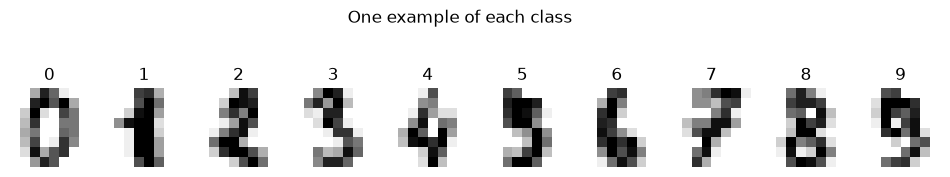


Training set : 1347 images
Test set     : 450 images
Label '2' one-hot encoded -> [0 0 1 0 0 0 0 0 0 0]


In [1]:
# Setup for 10-class digit recognition: load the 8x8 digits, scale pixels to [0,1],
# split stratified, and one-hot encode labels — the standard multiclass pipeline.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

digits = load_digits()
X_raw, y, images = digits.data, digits.target, digits.images

print(f"Dataset      : {X_raw.shape[0]} images, {X_raw.shape[1]} features (8x8 pixels)")
print(f"Classes      : {np.unique(y).tolist()}")
print(f"Pixel range  : {X_raw.min():.0f} to {X_raw.max():.0f}")

# One example of each digit
# Look at the data first: one sample image per class.
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for d, ax in enumerate(axes):
    ax.imshow(images[y == d][0], cmap="gray_r")
    ax.set_title(str(d))
    ax.axis("off")
plt.suptitle("One example of each class", y=1.15)
plt.show()

# Scale, split (stratified), one-hot encode
# Scale, split, and one-hot encode: softmax + categorical crossentropy expect one column per class.
X = X_raw / 16.0
idx_train, idx_test = train_test_split(
    np.arange(len(X)), test_size=450, random_state=42, stratify=y)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
Y_train, Y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)

print(f"\nTraining set : {len(X_train)} images")
print(f"Test set     : {len(X_test)} images")
print(f"Label '{y_train[0]}' one-hot encoded -> {Y_train[0].astype(int)}")

## 2. Baseline: an MLP with One Hidden Layer

The baseline model has three parts:

- `Dense(32, activation="relu")` — a hidden layer of 32 neurons that learns pixel patterns;
- `Dense(10, activation="softmax")` — ten output neurons, one per digit. Softmax
  turns their raw scores into **probabilities that sum to 1**, so the network's
  answer is "how confident am I in each of the ten digits";
- `loss="categorical_crossentropy"` — punishes the model when it puts low
  probability on the true class. Softmax + one-hot labels + categorical
  crossentropy is *the* standard recipe for multi-class classification.

We train for 15 epochs, holding out 15% of the training set for validation, and
print loss/accuracy per epoch.

In [2]:
# Train the baseline MLP: 64 pixels in, softmax over 10 digits out. The epoch table
# shows train AND validation metrics — the pair to watch for overfitting.
EPOCHS = 15

def build_and_train(hidden_layers, tag):
    keras.utils.set_random_seed(42)
    model = Sequential([Input(shape=(64,))]
                       + [Dense(n, activation="relu") for n in hidden_layers]
                       + [Dense(10, activation="softmax")])
    model.compile(optimizer="adam", loss="categorical_crossentropy",
                  metrics=["accuracy"])
    history = model.fit(X_train, Y_train, epochs=EPOCHS, batch_size=32,
                        validation_split=0.15, verbose=0)
    print(f"[{tag}] hidden layers {hidden_layers} -> "
          f"{model.count_params()} trainable parameters")
    return model, history.history

# Train the 1-hidden-layer baseline and print its learning curve as a table.
model1, hist1 = build_and_train([32], "baseline")

print(f"\n{'epoch':>5} | {'loss':>7} | {'acc':>6} | {'val_loss':>8} | {'val_acc':>7}")
print("-" * 46)
for e in range(EPOCHS):
    print(f"{e + 1:>5} | {hist1['loss'][e]:>7.4f} | {hist1['accuracy'][e]:>6.3f} | "
          f"{hist1['val_loss'][e]:>8.4f} | {hist1['val_accuracy'][e]:>7.3f}")

test_loss1, test_acc1 = model1.evaluate(X_test, Y_test, verbose=0)
print(f"\nBaseline test accuracy: {test_acc1:.3f}  (test loss {test_loss1:.4f})")

[baseline] hidden layers [32] -> 2410 trainable parameters

epoch |    loss |    acc | val_loss | val_acc
----------------------------------------------
    1 |  2.2208 |  0.113 |   2.0919 |   0.217
    2 |  1.9381 |  0.428 |   1.7850 |   0.557
    3 |  1.6221 |  0.622 |   1.4518 |   0.685
    4 |  1.3123 |  0.742 |   1.1526 |   0.808
    5 |  1.0482 |  0.837 |   0.9269 |   0.867
    6 |  0.8500 |  0.885 |   0.7611 |   0.892
    7 |  0.7062 |  0.902 |   0.6410 |   0.897
    8 |  0.6007 |  0.914 |   0.5516 |   0.901
    9 |  0.5215 |  0.924 |   0.4830 |   0.921
   10 |  0.4594 |  0.934 |   0.4278 |   0.926
   11 |  0.4102 |  0.935 |   0.3847 |   0.926
   12 |  0.3708 |  0.938 |   0.3502 |   0.931
   13 |  0.3385 |  0.939 |   0.3220 |   0.931
   14 |  0.3117 |  0.941 |   0.2986 |   0.931
   15 |  0.2889 |  0.946 |   0.2792 |   0.931

Baseline test accuracy: 0.933  (test loss 0.2893)


## 3. Training Curves

The per-epoch table is easier to judge as a picture. Two things to check:
does the loss keep falling (still learning?), and does the validation curve track
the training curve (or drift away, which would signal overfitting)?

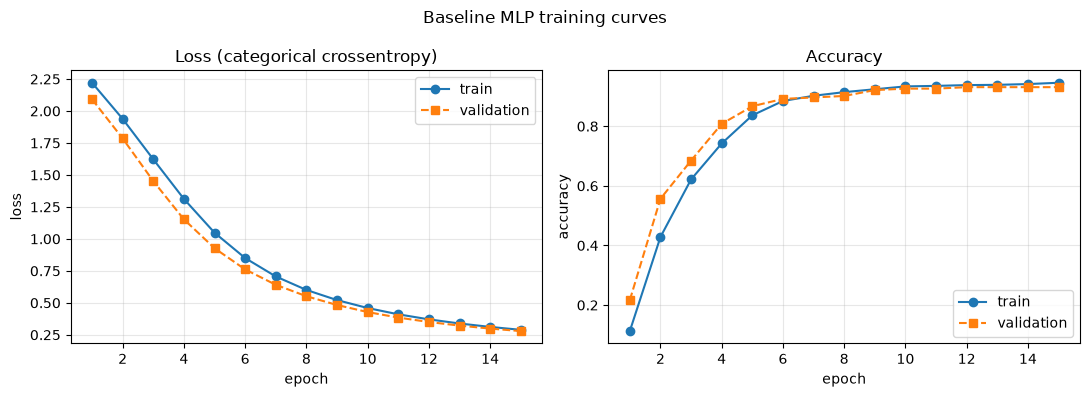

Loss fell from 2.221 (epoch 1) to 0.289 (epoch 15).
Final gap train vs validation accuracy: +0.015


In [3]:
# The same history as pictures: loss and accuracy per epoch for train vs validation.
# Parallel falling curves = healthy; a widening gap = memorization starting.
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs_range, hist1["loss"], "o-", label="train")
ax1.plot(epochs_range, hist1["val_loss"], "s--", label="validation")
ax1.set_title("Loss (categorical crossentropy)")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_range, hist1["accuracy"], "o-", label="train")
ax2.plot(epochs_range, hist1["val_accuracy"], "s--", label="validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle("Baseline MLP training curves")
plt.tight_layout()
plt.show()

print(f"Loss fell from {hist1['loss'][0]:.3f} (epoch 1) to {hist1['loss'][-1]:.3f} (epoch {EPOCHS}).")
print(f"Final gap train vs validation accuracy: "
      f"{hist1['accuracy'][-1] - hist1['val_accuracy'][-1]:+.3f}")

## 4. Where Does It Go Wrong? Confusion Matrix and Real Mistakes

Overall accuracy hides *which* digits get confused with which. The confusion
matrix counts every (true digit, predicted digit) pair on the test set — a perfect
model would put all counts on the diagonal. We then look at a few actual
misclassified images to see whether the mistakes are understandable.

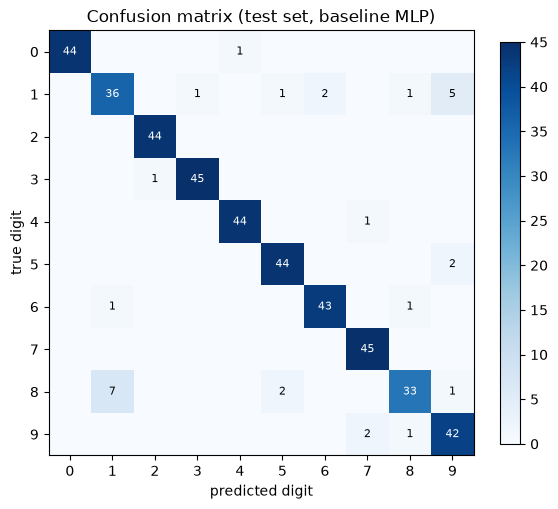

Misclassified: 30 of 450 test images (6.7%)


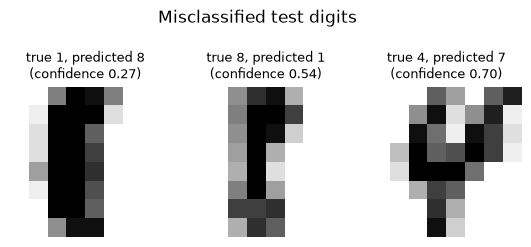

  image #0: true=1  predicted=8  confidence=0.27
  image #25: true=8  predicted=1  confidence=0.54
  image #28: true=4  predicted=7  confidence=0.70


In [4]:
# Beyond a single accuracy number: the confusion matrix shows WHICH digits get mixed
# up, and the misclassified images show WHY — often genuinely ambiguous handwriting.
from sklearn.metrics import confusion_matrix

probs = model1.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted digit"); ax.set_ylabel("true digit")
ax.set_title("Confusion matrix (test set, baseline MLP)")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=8)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

# Inspect a few individual failures; note the model's confidence on each.
wrong = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(wrong)} of {len(y_test)} test images "
      f"({len(wrong) / len(y_test):.1%})")

show = wrong[:3]
fig, axes = plt.subplots(1, len(show), figsize=(2.2 * len(show), 2.6))
for ax, k in zip(np.atleast_1d(axes), show):
    ax.imshow(images[idx_test[k]], cmap="gray_r")
    ax.set_title(f"true {y_test[k]}, predicted {y_pred[k]}\n"
                 f"(confidence {probs[k].max():.2f})", fontsize=9)
    ax.axis("off")
plt.suptitle("Misclassified test digits", y=1.08)
plt.show()

for k in show:
    print(f"  image #{k}: true={y_test[k]}  predicted={y_pred[k]}  "
          f"confidence={probs[k].max():.2f}")

## 5. Change One Thing: Add a Second Hidden Layer

Would a deeper network do better? We keep everything identical — data, loss,
optimizer, epochs, seed — and change only the architecture: a second hidden layer
of 16 ReLU neurons between the existing hidden layer and the softmax output.
Then we put both models side by side.

In [5]:
# Does a second hidden layer help? Same training budget, one architecture change —
# compare parameters and test accuracy to judge whether the extra depth pays for itself.
model2, hist2 = build_and_train([32, 16], "2-hidden-layer")
test_loss2, test_acc2 = model2.evaluate(X_test, Y_test, verbose=0)

rows = [
    ("1 hidden layer  [32]",      model1, hist1, test_acc1),
    ("2 hidden layers [32, 16]",  model2, hist2, test_acc2),
]
print(f"\n{'model':<26} | {'params':>6} | {'train acc':>9} | {'val acc':>7} | {'test acc':>8}")
print("-" * 70)
for name, model, hist, test_acc in rows:
    print(f"{name:<26} | {model.count_params():>6} | {hist['accuracy'][-1]:>9.3f} | "
          f"{hist['val_accuracy'][-1]:>7.3f} | {test_acc:>8.3f}")

diff = test_acc2 - test_acc1
print(f"\nTest-accuracy difference (2-layer minus 1-layer): {diff:+.3f} "
      f"({abs(diff) * len(y_test):.0f} test images)")

[2-hidden-layer] hidden layers [32, 16] -> 2778 trainable parameters

model                      | params | train acc | val acc | test acc
----------------------------------------------------------------------
1 hidden layer  [32]       |   2410 |     0.946 |   0.931 |    0.933
2 hidden layers [32, 16]   |   2778 |     0.945 |   0.906 |    0.938

Test-accuracy difference (2-layer minus 1-layer): +0.004 (2 test images)


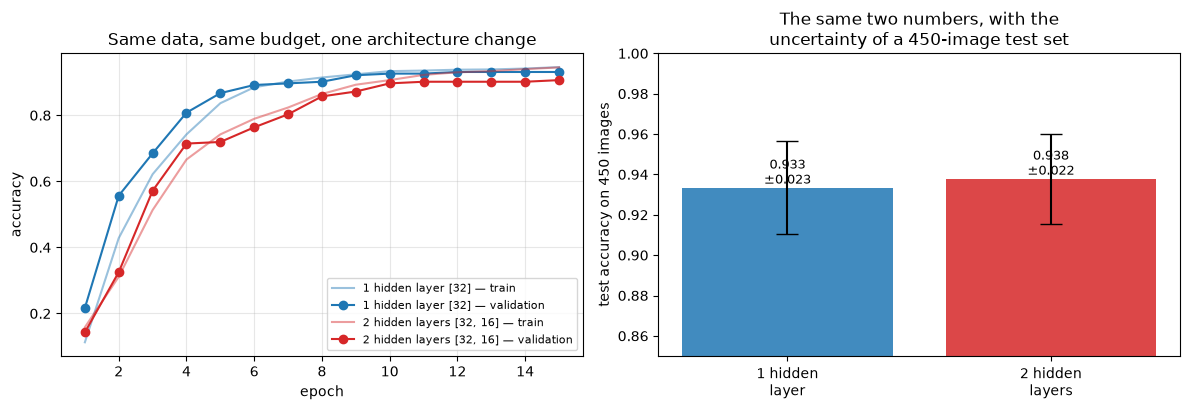

Final validation accuracy: 1 layer 0.931, 2 layers 0.906 (-2.5 points)
Test accuracy            : 1 layer 0.933, 2 layers 0.938 (+0.4 points = 2 images)
95% interval half-width on 450 test images: ±0.023 — about 10 images wide either way.
The two intervals overlap almost completely: this test set cannot tell these
two models apart, in either direction.


In [6]:
# WHAT/WHY: the table above compares two architectures with four numbers; this cell
# draws the same two runs so the comparison can be judged instead of read.
# Left: every epoch of both runs. Right: the two test scores WITH the uncertainty a
# 450-image test set carries — the honest way to look at a 0.004 difference.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))

for hist, name, color in [(hist1, "1 hidden layer [32]", "tab:blue"),
                          (hist2, "2 hidden layers [32, 16]", "tab:red")]:
    axL.plot(epochs_range, hist["accuracy"], "-", color=color, alpha=0.45,
             label=f"{name} — train")
    axL.plot(epochs_range, hist["val_accuracy"], "o-", color=color,
             label=f"{name} — validation")
axL.set_title("Same data, same budget, one architecture change")
axL.set_xlabel("epoch"); axL.set_ylabel("accuracy")
axL.legend(fontsize=8, loc="lower right"); axL.grid(alpha=0.3)

# 95% confidence interval for an accuracy measured on n test images:
# 1.96 * sqrt(p(1-p)/n) — the sampling noise of the test set itself.
n_test = len(y_test)
accs = [test_acc1, test_acc2]
errs = [1.96 * np.sqrt(a * (1 - a) / n_test) for a in accs]
bars = axR.bar(["1 hidden\nlayer", "2 hidden\nlayers"], accs, yerr=errs, capsize=8,
               color=["tab:blue", "tab:red"], alpha=0.85)
axR.set_ylim(0.85, 1.0)
axR.set_ylabel(f"test accuracy on {n_test} images")
axR.set_title("The same two numbers, with the\nuncertainty of a 450-image test set")
for b, a, e in zip(bars, accs, errs):
    axR.annotate(f"{a:.3f}\n±{e:.3f}", (b.get_x() + b.get_width() / 2, a),
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: 1 layer {hist1['val_accuracy'][-1]:.3f}, "
      f"2 layers {hist2['val_accuracy'][-1]:.3f} "
      f"({(hist2['val_accuracy'][-1] - hist1['val_accuracy'][-1]) * 100:+.1f} points)")
print(f"Test accuracy            : 1 layer {test_acc1:.3f}, 2 layers {test_acc2:.3f} "
      f"({(test_acc2 - test_acc1) * 100:+.1f} points = "
      f"{abs(test_acc2 - test_acc1) * n_test:.0f} images)")
print(f"95% interval half-width on {n_test} test images: "
      f"±{errs[0]:.3f} — about {errs[0] * n_test:.0f} images wide either way.")
print("The two intervals overlap almost completely: this test set cannot tell these")
print("two models apart, in either direction.")


### 👀 Read the comparison

**Left panel.** The two validation curves (circles) are tangled together for most of
training; the deeper model starts slower — it has an extra layer of random weights to
sort out — and ends *below* the shallower one (0.906 vs 0.931). The pale train curves run *below* their own
validation curves for most of the run — training accuracy is averaged over an epoch while
validation is scored once at the end of it — and only cross above at the finish: 0.946 vs
0.931 for the shallow model, 0.945 vs 0.906 for the deeper one. Neither gap widens as
training goes on, so neither model is memorising the training set at this size.

**Right panel.** The two test scores, 0.933 and 0.938, with the 95% interval a 450-image
test set actually supports: about **±0.023**, roughly ten images either way. The
difference between the models is **two images**. The error bars overlap almost entirely,
so this test set cannot rank these two architectures — and neither can you, from this
run.

**What that is worth as a habit.** The instinct on seeing 0.938 > 0.933 is to report that
the deeper model is better. The bar chart is the reason not to: before a gap counts as a
result it has to be larger than the noise of the set you measured it on. A comparison
without that check is decoration.

## 💬 Discuss

Everything you need was printed: baseline test accuracy **0.933** (30 of 450
wrong), the two-hidden-layer model at **0.938** with *lower* validation accuracy
(0.906 vs 0.931), the most common confusion **1 ↔ 8**, and three misclassified
images with confidences **0.27**, **0.54** and **0.70**.

1. The deeper model won on test (+0.004, **two images**) and lost on validation
   (−0.025). **Which number would you report, and which model would you ship?**
   Say what you would have to run before you were willing to claim either model is
   better than the other.
2. Image #0 was called an 8 with confidence **0.27** — the network's top choice
   was barely ahead of its second. In the Street View pipeline that reading would
   be sent to a human or dropped. **Design the rule:** below what confidence would
   you refuse to answer, and what does refusing cost the user of your system?
3. Softmax always returns a distribution that sums to 1. Feed this model a
   photograph of a cat and it will still name a digit, with a confidence.
   **Is that a bug in softmax, a bug in the design, or a bug in how the output is
   used?** Argue it, then say where the fix belongs.
4. The most common confusion is 1 ↔ 8 at 8×8 pixels. On a bank cheque, which
   single digit confusion would you most want to eliminate, and why does the
   *position* of the digit matter to your answer?


---

## ✅ Summary

**What the outputs actually show:**

- The baseline MLP (one hidden layer, softmax output, categorical crossentropy)
  learns fast: loss falls from 2.22 to 0.29 in 15 epochs and test accuracy reaches
  **0.933** (30 of 450 test images wrong, 6.7%). The loss is still falling at epoch
  15 — we stop early to keep the notebook fast, and a longer budget would keep
  improving the model.
- The training curves show validation tracking training closely (final accuracy
  gap about 1.5 points) — no serious overfitting at this size.
- The confusion matrix is strongly diagonal. The most common mix-up is **1 ↔ 8**,
  and the misclassified images show why: at 8×8 resolution, a thick "1" and a
  narrow "8" are nearly the same blob of pixels.
- Adding a second hidden layer changed test accuracy from 0.933 to 0.938 — a
  difference of just **2 test images** — while validation accuracy came out
  slightly *lower*. At the same training budget, extra depth bought no meaningful
  accuracy on this small, easy dataset: depth is not free accuracy.

**The recipe to remember** for any multi-class problem in Keras:
one output neuron *per class*, `softmax` activation, one-hot labels, and
`categorical_crossentropy` loss.

---

## ⚠️ Where this breaks

- **Softmax cannot say "none of these".** It normalises whatever scores it is
  given, so an input from outside all ten classes still produces a confident-looking
  distribution. Any deployed classifier needs an explicit rejection mechanism — a
  confidence threshold, an out-of-distribution detector, or an eleventh "other"
  class trained on negatives. Our notebook has none of the three.
- **Softmax confidence is not calibrated probability.** A network reporting 0.90
  is not right 90% of the time; neural networks are typically over-confident, and
  the fix (temperature scaling, or measuring a reliability curve) is a separate
  step nobody performed here.
- **The 2-image difference between the two models is noise.** On 450 test images,
  a shift of ±0.004 is well inside the run-to-run variation of a single seed.
  Reporting it as an improvement — in either direction — is not supportable, and
  the validation numbers going the *other* way is the evidence.
- **Accuracy hides which class fails.** The confusion matrix is the honest report,
  and on a balanced 10-class dataset it is still generous: on an imbalanced problem
  overall accuracy can be high while a rare class is never predicted at all.
- **8×8 pixels is the ceiling, not the model.** A thick 1 and a narrow 8 are
  nearly the same blob at this resolution — you can see it in the printed
  misclassified images. No amount of depth recovers information the sensor never
  captured.
- **The loss was still falling at epoch 15.** We stopped early to keep the
  notebook fast. Neither this model's accuracy nor the depth comparison is a
  converged result, and comparing two architectures at an arbitrary shared budget
  can reverse when both are trained to convergence.
- **An MLP throws away the image's geometry.** Flattening 8×8 into 64 independent
  inputs means shuffling every image's pixels in the same way would not change what
  the model can learn. Notebook 05 measures what convolutions recover.


## 📚 References

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323, 533–536.
2. Bridle, J. S. (1990). *Probabilistic Interpretation of Feedforward Classification Network Outputs, with Relationships to Statistical Pattern Recognition* (softmax). In Neurocomputing: Algorithms, Architectures and Applications, Springer.
3. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6: Deep Feedforward Networks (includes the XOR example). MIT Press.
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv. <https://arxiv.org/abs/2605.13986>
6. Yang, A., Li, A., Yang, B., et al. (2025). *Qwen3 Technical Report*. arXiv. <https://arxiv.org/abs/2505.09388>